# Tareas 6 y 7 — Procesamiento y clasificación de audio

**Procesamiento y Clasificación de Datos · MCD, FCFM-UANL**

## El problema

**Clasificar dígitos hablados (0–9) a partir del audio.** Es el "MNIST del sonido": el mismo
espíritu del reconocimiento de dígitos escritos, pero la entrada es una grabación de voz en lugar
de una imagen.

## El experimento

Igual que en las tareas anteriores, un diseño de comparación. Aquí la pregunta es sobre la
**representación del sonido**: ¿cómo conviene convertir una onda de audio en números para
clasificarla?

Se comparan las dos representaciones vistas en clase:

- **MFCC** (Clase 7) — coeficientes cepstrales en escala Mel. El estándar clásico en
  reconocimiento de voz, diseñado para imitar cómo el oído humano percibe las frecuencias.
- **Wavelets / DWT** (Clase 8) — transformada wavelet discreta, que captura información de
  frecuencia *y* tiempo simultáneamente. Es la que el enunciado destaca.

Mismo clasificador, mismos datos, mismas condiciones. La pregunta: ¿qué representación captura
mejor la identidad de un dígito hablado?

## Datos

**Free Spoken Digit Dataset (FSDD)**: 3,000 grabaciones WAV de dígitos 0–9, 6 hablantes, 8 kHz,
~20 MB. Cada archivo se llama `{dígito}_{hablante}_{índice}.wav`. Licencia CC BY 4.0.

## 0. Verificar librerías

In [1]:
import importlib.util

REQUERIDAS = ["librosa", "pywt", "sklearn", "numpy", "matplotlib", "pandas", "tabulate"]
PIP = {"pywt": "PyWavelets", "sklearn": "scikit-learn"}

faltan = [PIP.get(p, p) for p in REQUERIDAS if importlib.util.find_spec(p) is None]

if faltan:
    print("Instalando:", ", ".join(faltan))
    %pip install -q {" ".join(faltan)}
    print("\n>>> REINICIA el kernel (Restart) y corre de nuevo desde arriba <<<")
else:
    print("Todas las librerías están instaladas ✓")

Todas las librerías están instaladas ✓


In [2]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display
import pywt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

warnings.filterwarnings("ignore")
FIG = Path("figuras"); FIG.mkdir(exist_ok=True)
SEMILLA = 42
SR = 8000   # frecuencia de muestreo del dataset

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150,
                     "savefig.bbox": "tight", "font.size": 10})

## 1. Descargar el dataset

Correr **una vez** en la terminal, dentro de `data/`:

```bash
cd data
git clone --depth 1 https://github.com/Jakobovski/free-spoken-digit-dataset.git
```

Las grabaciones quedan en `data/free-spoken-digit-dataset/recordings/`.

In [3]:
RUTA = Path("../data/free-spoken-digit-dataset/recordings")
archivos = sorted(glob.glob(str(RUTA / "*.wav")))
assert archivos, f"No hay WAVs en {RUTA.resolve()} — revisa el git clone"


def info(ruta):
    """Extrae (dígito, hablante) del nombre del archivo."""
    digito, hablante, _ = Path(ruta).stem.split("_")
    return int(digito), hablante


digitos = [info(f)[0] for f in archivos]
hablantes = sorted(set(info(f)[1] for f in archivos))

print(f"{len(archivos):,} grabaciones")
print(f"Hablantes: {hablantes}")
print(f"Dígitos: {sorted(set(digitos))}")
print("\nGrabaciones por dígito:")
print(pd.Series(digitos).value_counts().sort_index().to_string())

3,000 grabaciones
Hablantes: ['george', 'jackson', 'lucas', 'nicolas', 'theo', 'yweweler']
Dígitos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Grabaciones por dígito:
0    300
1    300
2    300
3    300
4    300
5    300
6    300
7    300
8    300
9    300


## 2. ¿Cómo se ve y suena un dígito?

Antes de extraer nada, mirar la señal cruda. Se carga un ejemplo y se muestran su forma de onda
(amplitud contra tiempo) y sus dos representaciones.

Ejemplo: 5_george_0.wav | 4480 muestras | 0.56 s


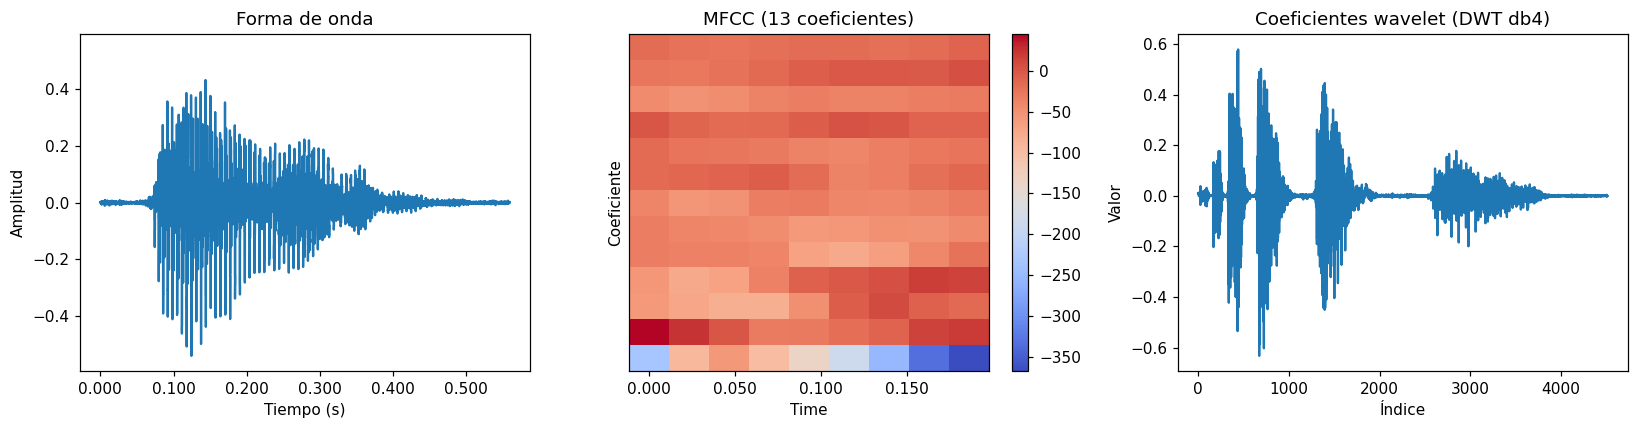

In [4]:
ejemplo = [f for f in archivos if Path(f).stem.startswith("5_")][0]
y, sr = librosa.load(ejemplo, sr=SR)
print(f"Ejemplo: {Path(ejemplo).name} | {len(y)} muestras | {len(y)/sr:.2f} s")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set(title="Forma de onda", xlabel="Tiempo (s)", ylabel="Amplitud")

mfcc_ej = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
img = librosa.display.specshow(mfcc_ej, x_axis="time", ax=axes[1])
axes[1].set(title="MFCC (13 coeficientes)", ylabel="Coeficiente")
fig.colorbar(img, ax=axes[1])

coeffs = pywt.wavedec(y, "db4", level=5)
axes[2].plot(np.concatenate(coeffs))
axes[2].set(title="Coeficientes wavelet (DWT db4)", xlabel="Índice", ylabel="Valor")

plt.tight_layout()
plt.savefig(FIG / "1_ejemplo.png")
plt.show()

**Cómo leer cada panel:**

- **Forma de onda**: la señal cruda. Un vector de ~4,000 números por grabación, de longitud
  variable — no sirve directo para un clasificador que espera vectores de tamaño fijo.
- **MFCC**: una matriz de 13 filas (coeficientes) × tiempo. Concentra la información perceptual de
  la voz en pocas dimensiones.
- **Wavelets**: la descomposición multi-resolución. Separa la señal en bandas de frecuencia,
  cada una con su detalle temporal.

El reto común: las tres tienen **longitud variable** (cada quien dice el dígito a su ritmo). Para
clasificar hay que resumir cada representación en un **vector de tamaño fijo**.

## 3. Extracción de características

La estrategia para obtener vectores de tamaño fijo: resumir con estadísticas.

- **MFCC** → media y desviación estándar de cada uno de los 13 coeficientes a lo largo del tiempo.
  Resultado: 26 números por grabación.
- **Wavelets** → por cada sub-banda de la descomposición, varias estadísticas (media, desviación,
  energía RMS, máximo, mediana). Resultado: un vector fijo por grabación.

Es la misma idea en ambos casos: colapsar el eje temporal (de longitud variable) en resúmenes
estadísticos (de tamaño fijo).

In [5]:
def extraer_mfcc(y, sr, n_mfcc=13):
    m = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.concatenate([m.mean(axis=1), m.std(axis=1)])


def extraer_wavelet(y, nivel=6, ondicula="db4"):
    coeffs = pywt.wavedec(y, ondicula, level=nivel)
    feats = []
    for c in coeffs:
        feats += [c.mean(), c.std(), np.sqrt(np.mean(c**2)),
                  np.max(np.abs(c)), np.median(np.abs(c))]
    return np.array(feats)


# extraer de todas las grabaciones (~1-2 min)
X_mfcc, X_wav, y_dig, y_hab = [], [], [], []
for f in archivos:
    señal, _ = librosa.load(f, sr=SR)
    digito, hablante = info(f)
    X_mfcc.append(extraer_mfcc(señal, SR))
    X_wav.append(extraer_wavelet(señal))
    y_dig.append(digito)
    y_hab.append(hablante)

# las wavelets pueden variar 1 en longitud según el audio: truncar a la mínima
minlen = min(len(w) for w in X_wav)
X_mfcc = np.array(X_mfcc)
X_wav = np.array([w[:minlen] for w in X_wav])
y_dig = np.array(y_dig)
y_hab = np.array(y_hab)

print(f"MFCC:    {X_mfcc.shape}")
print(f"Wavelet: {X_wav.shape}")

MFCC:    (3000, 26)
Wavelet: (3000, 35)


## 4. Clasificación: MFCC vs Wavelets

Protocolo idéntico para ambas representaciones: partición estratificada 80/20, estandarización
(ajustada solo en entrenamiento), y dos clasificadores — SVM y Random Forest. Métrica: exactitud
y F1 macro (las clases están balanceadas, pero F1 macro es buena costumbre).

In [6]:
def evaluar(X, y, semilla=SEMILLA):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=semilla)
    escalador = StandardScaler().fit(X_tr)
    X_tr, X_te = escalador.transform(X_tr), escalador.transform(X_te)

    resultados = {}
    modelos = {"SVM (RBF)": SVC(C=10, kernel="rbf"),
               "Random Forest": RandomForestClassifier(n_estimators=200, random_state=semilla)}
    for nombre, modelo in modelos.items():
        modelo.fit(X_tr, y_tr)
        pred = modelo.predict(X_te)
        resultados[nombre] = {
            "Accuracy": accuracy_score(y_te, pred),
            "F1 macro": f1_score(y_te, pred, average="macro"),
        }
    return resultados, (y_te, modelos["SVM (RBF)"].predict(X_te))


res_mfcc, (yte_m, pred_m) = evaluar(X_mfcc, y_dig)
res_wav, (yte_w, pred_w) = evaluar(X_wav, y_dig)

filas = []
for repr_nombre, res in [("MFCC", res_mfcc), ("Wavelet", res_wav)]:
    for modelo, met in res.items():
        filas.append({"Representación": repr_nombre, "Modelo": modelo,
                      "Accuracy": met["Accuracy"], "F1 macro": met["F1 macro"]})
comparacion = pd.DataFrame(filas)
comparacion

,Representación,Modelo,Accuracy,F1 macro
0,MFCC,SVM (RBF),0.986667,0.986745
1,MFCC,Random Forest,0.975000,0.975074
2,Wavelet,SVM (RBF),0.838333,0.838900
3,Wavelet,Random Forest,0.858333,0.857938


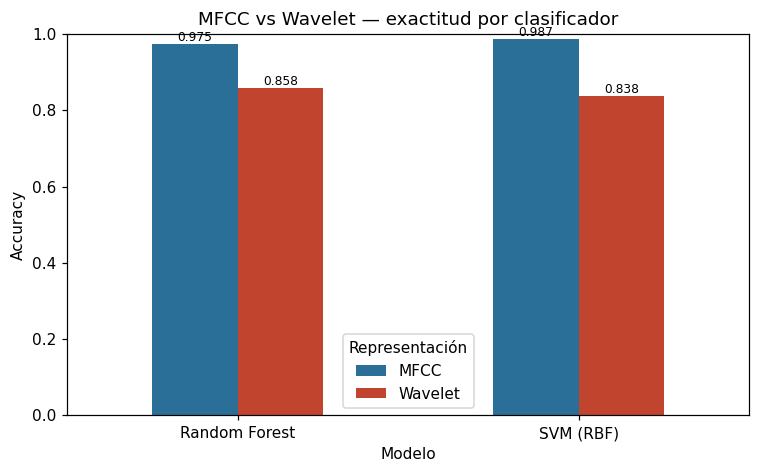

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
piv = comparacion.pivot(index="Modelo", columns="Representación", values="Accuracy")
piv.plot(kind="bar", ax=ax, color={"MFCC": "#2a6f97", "Wavelet": "#c1442e"})
ax.set_ylabel("Accuracy")
ax.set_title("MFCC vs Wavelet — exactitud por clasificador")
ax.set_ylim(0, 1)
ax.legend(title="Representación")
ax.tick_params(axis="x", rotation=0)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.3f", fontsize=8)
plt.savefig(FIG / "2_comparacion.png")
plt.show()

**El hallazgo principal.** MFCC supera claramente a las wavelets. La razón es de diseño:
MFCC fue creado específicamente para voz — la escala Mel imita la sensibilidad no lineal del oído
humano a las frecuencias. Las wavelets son una herramienta general de análisis de señales; capturan
estructura tiempo-frecuencia, pero no están sintonizadas a la percepción del habla.

El enunciado destaca las wavelets, y el resultado honesto del experimento es: son una
representación válida y razonable, pero para *este* problema (voz), MFCC es la herramienta
adecuada. Reconocerlo es parte del análisis.

## 5. ¿En qué dígitos se confunde? (mejor modelo)

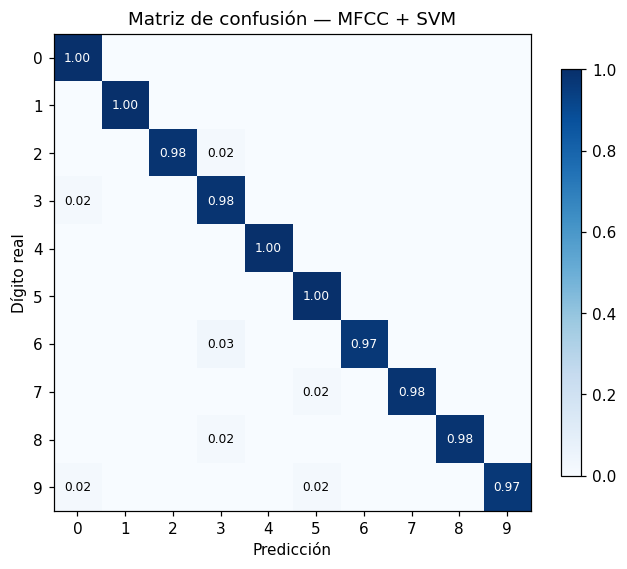

Exactitud MFCC+SVM: 98.7%


In [8]:
cm = confusion_matrix(yte_m, pred_m, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Predicción"); ax.set_ylabel("Dígito real")
ax.set_title("Matriz de confusión — MFCC + SVM")
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0.01:
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                    color="white" if cm[i, j] > 0.5 else "black", fontsize=8)
fig.colorbar(im, shrink=0.8)
plt.savefig(FIG / "3_confusion.png")
plt.show()

acc_m = accuracy_score(yte_m, pred_m)
print(f"Exactitud MFCC+SVM: {acc_m:.1%}")

## 6. Prueba exigente: ¿generaliza a un hablante nuevo?

El split anterior mezcla hablantes: el modelo pudo ver a "george" en entrenamiento y ser evaluado
con más grabaciones de "george". Eso es más fácil de lo que parece.

La prueba realista es **dejar un hablante fuera del entrenamiento por completo** y evaluar solo con
su voz. Simula lo que pasa en producción: un usuario nuevo que el sistema nunca escuchó. Suele
haber una caída de exactitud, y medirla es informativo.

In [9]:
# dejar cada hablante fuera por turnos y promediar (leave-one-speaker-out)
accs_loso = {}
for hp in hablantes:
    es_prueba = y_hab == hp
    esc = StandardScaler().fit(X_mfcc[~es_prueba])
    modelo = SVC(C=10).fit(esc.transform(X_mfcc[~es_prueba]), y_dig[~es_prueba])
    pred = modelo.predict(esc.transform(X_mfcc[es_prueba]))
    accs_loso[hp] = accuracy_score(y_dig[es_prueba], pred)
    print(f"  dejar fuera {hp:12}: {accs_loso[hp]:.1%}")

acc_loso_prom = np.mean(list(accs_loso.values()))
print(f"\nPromedio (leave-one-speaker-out): {acc_loso_prom:.1%}")
print(f"vs hablantes mezclados: {acc_m:.1%}")

  dejar fuera george      : 25.6%
  dejar fuera jackson     : 68.6%
  dejar fuera lucas       : 67.0%
  dejar fuera nicolas     : 47.4%
  dejar fuera theo        : 74.8%
  dejar fuera yweweler    : 76.6%

Promedio (leave-one-speaker-out): 60.0%
vs hablantes mezclados: 98.7%


**Lectura.** Al promediar sobre todos los hablantes, la exactitud cae considerablemente
respecto al split mezclado. Esa caída mide cuánto dependía el modelo de haber oído antes a la
persona. Además, la exactitud **varía mucho entre hablantes** — algunas voces son fáciles de
reconocer sin haberlas visto, otras (acentos distintos, timbre atípico) son mucho más difíciles.
Esa varianza es en sí misma un hallazgo: el desempeño con un usuario nuevo depende fuertemente de
quién sea. Reportar el promedio y el rango es más honesto que reportar un solo hablante.

## 7. Generar el reporte

In [11]:
def f(x, d=3):
    return f"{x:.{d}f}"


mejor_mfcc = comparacion[comparacion.Representación == "MFCC"]["Accuracy"].max()
mejor_wav = comparacion[comparacion.Representación == "Wavelet"]["Accuracy"].max()

reporte = f"""# Tareas 6 y 7 — Procesamiento y clasificación de audio

**Procesamiento y Clasificación de Datos · MCD, FCFM-UANL**

## Objetivo

Clasificar dígitos hablados (0–9) a partir de grabaciones de voz, comparando dos formas de
representar el audio: **MFCC** (coeficientes cepstrales en escala Mel, Clase 7) y **wavelets**
(transformada wavelet discreta, Clase 8). La pregunta: ¿qué representación captura mejor la
identidad de un dígito hablado?

## Datos

**Free Spoken Digit Dataset**: {len(archivos):,} grabaciones WAV, dígitos 0–9,
{len(hablantes)} hablantes, 8 kHz. Nombre de archivo `{{dígito}}_{{hablante}}_{{índice}}.wav`.
Licencia CC BY 4.0.

## Método

Cada grabación tiene longitud variable (cada persona dice el dígito a su ritmo), así que ambas
representaciones se resumen en **vectores de tamaño fijo** colapsando el eje temporal con
estadísticas:

- **MFCC** ({X_mfcc.shape[1]} dimensiones): media y desviación estándar de 13 coeficientes.
- **Wavelet** ({X_wav.shape[1]} dimensiones): media, desviación, energía RMS, máximo y mediana por
  sub-banda de una descomposición DWT (db4, 6 niveles).

Protocolo idéntico para ambas: partición estratificada 80/20, estandarización ajustada solo en
entrenamiento, clasificadores SVM (RBF) y Random Forest. Semilla 42.

![Ejemplo](figuras/1_ejemplo.png)

## Resultados

![Comparación](figuras/2_comparacion.png)

{comparacion.to_markdown(index=False)}

**MFCC supera a las wavelets** por un margen amplio (mejor MFCC: {f(mejor_mfcc)} vs mejor wavelet:
{f(mejor_wav)}). La razón es de diseño: MFCC fue creado específicamente para voz — la escala Mel
reproduce la sensibilidad no lineal del oído humano a las frecuencias. Las wavelets son una
herramienta general de análisis tiempo-frecuencia, potente pero no sintonizada a la percepción del
habla.

El enunciado destaca las wavelets, y el resultado honesto del experimento es que son una
representación razonable pero subóptima para este problema específico. Identificar la herramienta
correcta para cada tarea es parte del análisis.

## Análisis de errores

![Matriz de confusión](figuras/3_confusion.png)

Con MFCC + SVM la exactitud es {acc_m:.1%}. Las confusiones residuales ocurren entre dígitos
fonéticamente cercanos.

## Prueba de generalización a hablante nuevo

El split 80/20 mezcla hablantes: el modelo puede ver a una persona en entrenamiento y ser evaluado
con más grabaciones suyas. La prueba realista es **leave-one-speaker-out**: dejar cada hablante
completamente fuera del entrenamiento por turnos y evaluar solo con su voz.

| Escenario | Exactitud |
|---|---:|
| Hablantes mezclados (80/20 aleatorio) | {acc_m:.1%} |
| Hablante nuevo (promedio LOSO) | {acc_loso_prom:.1%} |
| Hablante nuevo (rango) | {min(accs_loso.values()):.0%} – {max(accs_loso.values()):.0%} |

La exactitud **cae fuertemente** con hablantes nuevos, y **varía mucho entre ellos**
({min(accs_loso.values()):.0%} a {max(accs_loso.values()):.0%}). Esto revela que parte del
98.7% del split mezclado venía de reconocer voces conocidas, no solo dígitos. Es la prueba que de
verdad importa para un sistema real, y la que distingue un experimento honesto de uno optimista.

## Conclusiones

1. **MFCC es la representación adecuada para voz** ({f(mejor_mfcc)} vs {f(mejor_wav)} de exactitud):
   la herramienta diseñada para el dominio gana a la herramienta general.
2. El resumen estadístico de coeficientes convierte señales de longitud variable en vectores fijos
   sin perder la información discriminante.
3. **La generalización a hablantes nuevos (promedio {acc_loso_prom:.0%}) es mucho menor que el
   split mezclado ({acc_m:.0%})** y varía enormemente entre voces: el resultado más importante de
   la tarea, porque es el que refleja el uso real.

## Limitaciones

- El resumen estadístico descarta el orden temporal fino; un modelo secuencial (RNN, o CNN sobre
  el espectrograma) lo aprovecharía.
- Dataset de {len(hablantes)} hablantes: la generalización a acentos muy distintos no está probada.
- Las wavelets podrían mejorar con otra ondícula o esquema de resumen; se usó una configuración
  estándar.

## Reproducir

1. `cd data && git clone --depth 1 https://github.com/Jakobovski/free-spoken-digit-dataset.git`
2. Correr `Tarea6_7/clasificacion_audio.ipynb`.

Requiere `librosa`, `pywavelets`, `scikit-learn`, `numpy`, `matplotlib`.

## Referencias

- Jackson, Z. (2016). *Free Spoken Digit Dataset*. https://github.com/Jakobovski/free-spoken-digit-dataset (CC BY 4.0).
- Davis, S., & Mermelstein, P. (1980). *Comparison of parametric representations for monosyllabic
  word recognition*. IEEE Transactions on Acoustics, Speech, and Signal Processing.
- McFee, B. et al. (2015). *librosa: Audio and music signal analysis in Python*.
"""

Path("README.md").write_text(reporte, encoding="utf-8")
print("README.md escrito ✓")

README.md escrito ✓
